In [1]:
"""
DIVS Enhanced Pipeline (Train/Test 8:2 통일)
A) k=2 + 다중 모델 (LR, RF, XGBoost, LightGBM)
B) k=3 중간 제외 + 다중 모델

모든 실험: StratifiedSplit 8:2 → Train으로 학습 → Test로 평가
"""

import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score,
                             roc_curve, silhouette_score)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# LightGBM (없으면 스킵)
try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
    print("⚠️ LightGBM 미설치 → LR, RF, XGBoost 3개로 진행")

random_state = 42

In [2]:
# =============================================================
# 0. 데이터 로드
# =============================================================
cohort = pd.read_csv("cohort_preprocess_knn.csv")
snf = pd.read_csv("snf.csv").drop_duplicates(subset='HADM_ID')
cohort_orig = pd.read_csv("cohort_preprocess.csv")

df = cohort.merge(snf, on='HADM_ID', how='inner')
df_orig = cohort_orig.merge(snf, on='HADM_ID', how='inner')

df_snf = df[df['IS_SNF_PROXY'] == 1].copy()
df_non_snf = df[df['IS_SNF_PROXY'] == 0].copy()
df_orig_snf = df_orig[df_orig['IS_SNF_PROXY'] == 1].copy()

lab_cols = ['ALBUMIN', 'LYMPHOCYTES', 'TOTAL_PROTEIN']
cat_cols = [
    'GENDER', 'DEMENTIA_YN', 'PARKINSON_YN', 'CHF_YN',
    'CKD_YN', 'COPD_YN', 'CANCER_YN',
    'STEROID_YN', 'IMMUNOSUP_YN', 'ANTIPSYCHOTIC_YN'
]
num_cols_base = ['AGE']
cols_11 = num_cols_base + cat_cols

print(f"요양원: {len(df_snf)} | 비요양원: {len(df_non_snf)}")


요양원: 31993 | 비요양원: 155020


In [3]:
# =============================================================
# 1. Complete Case 추출 + 정규화
# =============================================================
snf_complete_mask = (
    df_orig_snf['ALBUMIN'].notna() &
    df_orig_snf['LYMPHOCYTES'].notna() &
    df_orig_snf['TOTAL_PROTEIN'].notna()
).values

df_snf_complete = df_snf[snf_complete_mask].copy()
df_snf_imputed = df_snf[~snf_complete_mask].copy()

scaler_lab = StandardScaler()
X_lab_scaled = scaler_lab.fit_transform(df_snf_complete[lab_cols])
complete_medians = df_snf_complete[lab_cols].median()

print(f"Complete case: {len(df_snf_complete)} ({len(df_snf_complete)/len(df_snf)*100:.1f}%)")

# =============================================================
# 공통 함수
# =============================================================
def assign_labels_km(data, scaler, km_model, high_risk_id, lab_cols, medians):
    X_lab = data[lab_cols].copy()
    for col in lab_cols:
        X_lab[col] = X_lab[col].fillna(medians[col])
    X_scaled = scaler.transform(X_lab)
    clusters = km_model.predict(X_scaled)
    return (clusters == high_risk_id).astype(int)

def get_models():
    models = {
        'Logistic Regression': LogisticRegression(
            random_state=random_state, max_iter=1000),
        'Random Forest': RandomForestClassifier(
            n_estimators=200, max_depth=10, min_samples_leaf=20,
            random_state=random_state, n_jobs=-1),
        'XGBoost': XGBClassifier(
            n_estimators=200, max_depth=5, learning_rate=0.1,
            min_child_weight=20, random_state=random_state,
            eval_metric='logloss', verbosity=0),
    }
    if HAS_LGBM:
        models['LightGBM'] = LGBMClassifier(
            n_estimators=200, max_depth=5, learning_rate=0.1,
            min_child_samples=20, random_state=random_state,
            verbose=-1)
    return models

def run_experiment_split(X_data, y_data, name):
    """Train/Test 8:2 split → 다중 모델 학습 + 평가"""
    print(f"\n{'='*60}")
    print(f"{name}")
    print(f"{'='*60}")

    X = pd.get_dummies(X_data, drop_first=True).astype(float)
    y = np.array(y_data)

    # 8:2 stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state, stratify=y)

    print(f"전체: {len(y)}명 | 고위험: {y.sum()} ({y.mean()*100:.1f}%)")
    print(f"Train: {len(X_train)} (고위험 {y_train.mean()*100:.1f}%)")
    print(f"Test:  {len(X_test)} (고위험 {y_test.mean()*100:.1f}%)")

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    models = get_models()
    results = {}

    for mname, model in models.items():
        m = model.__class__(**model.get_params())
        m.fit(X_train_s, y_train)

        prob_train = m.predict_proba(X_train_s)[:, 1]
        prob_test = m.predict_proba(X_test_s)[:, 1]
        pred_test = (prob_test >= 0.5).astype(int)

        auc_train = roc_auc_score(y_train, prob_train)
        auc_test = roc_auc_score(y_test, prob_test)

        results[mname] = {
            'auc_train': auc_train,
            'auc_test': auc_test,
            'f1': f1_score(y_test, pred_test),
            'acc': accuracy_score(y_test, pred_test),
            'y_test': y_test,
            'prob_test': prob_test
        }
        print(f"\n  [{mname}]")
        print(f"    Train AUC: {auc_train:.4f}")
        print(f"    Test AUC:  {auc_test:.4f}  (차이: {abs(auc_train-auc_test):.4f})")
        print(f"    Test F1:   {f1_score(y_test, pred_test):.4f}  "
              f"Acc: {accuracy_score(y_test, pred_test):.4f}")

    # 변수 중요도 (LR + RF)
    lr_final = LogisticRegression(random_state=random_state, max_iter=1000)
    lr_final.fit(X_train_s, y_train)
    rf_final = RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=20,
        random_state=random_state, n_jobs=-1)
    rf_final.fit(X_train_s, y_train)

    print(f"\n  [변수 중요도 (Train 기준)]")
    print(f"  {'변수':25s} {'LR 계수':>10s} {'RF 중요도':>10s}")
    coef_df = pd.DataFrame({
        'variable': X.columns,
        'lr_coef': lr_final.coef_[0],
        'rf_imp': rf_final.feature_importances_
    }).sort_values('rf_imp', ascending=False)
    for _, r in coef_df.iterrows():
        print(f"  {r['variable']:25s} {r['lr_coef']:+10.4f} {r['rf_imp']:10.4f}")

    return results

def run_experiment_mix(X_all, y_all, snf_flag, name):
    """혼합 실험: 요양원/비요양원 비율 유지하며 8:2 split"""
    print(f"\n{'='*60}")
    print(f"{name}")
    print(f"{'='*60}")

    X = pd.get_dummies(X_all, drop_first=True).astype(float)
    y = np.array(y_all)

    stratify_key = y * 10 + snf_flag.astype(int)

    X_train, X_test, y_train, y_test, snf_train, snf_test = train_test_split(
        X, y, snf_flag,
        test_size=0.2, random_state=random_state, stratify=stratify_key)

    print(f"전체: {len(y)}명 | 고위험: {y.sum()} ({y.mean()*100:.1f}%)")
    print(f"Train: {len(X_train)} (요양원 {snf_train.mean()*100:.1f}%, 고위험 {y_train.mean()*100:.1f}%)")
    print(f"Test:  {len(X_test)} (요양원 {snf_test.mean()*100:.1f}%, 고위험 {y_test.mean()*100:.1f}%)")

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    models = get_models()
    results = {}

    for mname, model in models.items():
        m = model.__class__(**model.get_params())
        m.fit(X_train_s, y_train)

        prob_train = m.predict_proba(X_train_s)[:, 1]
        prob_test = m.predict_proba(X_test_s)[:, 1]
        pred_test = (prob_test >= 0.5).astype(int)

        auc_train = roc_auc_score(y_train, prob_train)
        auc_test = roc_auc_score(y_test, prob_test)

        results[mname] = {
            'auc_train': auc_train,
            'auc_test': auc_test,
            'f1': f1_score(y_test, pred_test),
            'acc': accuracy_score(y_test, pred_test),
            'y_test': y_test,
            'prob_test': prob_test,
            'snf_test': snf_test
        }
        print(f"\n  [{mname}]")
        print(f"    Train AUC: {auc_train:.4f}")
        print(f"    Test AUC:  {auc_test:.4f}  (차이: {abs(auc_train-auc_test):.4f})")
        print(f"    Test F1:   {f1_score(y_test, pred_test):.4f}  "
              f"Acc: {accuracy_score(y_test, pred_test):.4f}")

        # subgroup 성능
        for label, mask in [("요양원", snf_test==1), ("비요양원", snf_test==0)]:
            if mask.sum() > 0 and len(np.unique(y_test[mask])) > 1:
                sub_auc = roc_auc_score(y_test[mask], prob_test[mask])
                print(f"      [{label}]: AUC = {sub_auc:.4f} (n={mask.sum()})")

    return results

Complete case: 6119 (19.1%)


In [4]:
# ##############################################################
# Part A: k=2 클러스터링 + 다중 모델
# ##############################################################
print(f"\n{'#'*60}")
print("Part A: k=2 클러스터링 + 다중 모델 (Train/Test 8:2)")
print(f"{'#'*60}")

km2 = KMeans(n_clusters=2, random_state=random_state, n_init=10)
cluster2 = km2.fit_predict(X_lab_scaled)

cluster2_means = pd.DataFrame(
    {col: df_snf_complete[col].values for col in lab_cols} | {'cluster': cluster2}
).groupby('cluster').mean()
high_risk_2 = cluster2_means['ALBUMIN'].idxmin()
y_complete_2 = (cluster2 == high_risk_2).astype(int)

y_snf_imp_2 = assign_labels_km(df_snf_imputed, scaler_lab, km2, high_risk_2, lab_cols, complete_medians)
y_snf_2 = np.zeros(len(df_snf), dtype=int)
y_snf_2[snf_complete_mask] = y_complete_2
y_snf_2[~snf_complete_mask] = y_snf_imp_2
y_non_snf_2 = assign_labels_km(df_non_snf, scaler_lab, km2, high_risk_2, lab_cols, complete_medians)

sil2 = silhouette_score(X_lab_scaled, cluster2)
print(f"\nk=2 실루엣: {sil2:.4f}")
print(f"고위험: {y_complete_2.sum()} ({y_complete_2.mean()*100:.1f}%)")

# 실험 1: 요양원만
r_a1 = run_experiment_split(
    df_snf[cols_11].reset_index(drop=True), y_snf_2,
    "Part A - 실험1: 요양원 (k=2)")

# 실험 2: 비요양원만
r_a2 = run_experiment_split(
    df_non_snf[cols_11].reset_index(drop=True), y_non_snf_2,
    "Part A - 실험2: 비요양원 (k=2)")

# 실험 3: 혼합
X_all_a = pd.concat([
    df_snf[cols_11].reset_index(drop=True),
    df_non_snf[cols_11].reset_index(drop=True)
], ignore_index=True)
y_all_a = np.concatenate([y_snf_2, y_non_snf_2])
snf_flag_a = np.concatenate([np.ones(len(df_snf)), np.zeros(len(df_non_snf))])

r_a3 = run_experiment_mix(
    X_all_a, y_all_a, snf_flag_a,
    "Part A - 실험3: 혼합 (k=2)")



############################################################
Part A: k=2 클러스터링 + 다중 모델 (Train/Test 8:2)
############################################################

k=2 실루엣: 0.2745
고위험: 2582 (42.2%)

Part A - 실험1: 요양원 (k=2)
전체: 31993명 | 고위험: 9892 (30.9%)
Train: 25594 (고위험 30.9%)
Test:  6399 (고위험 30.9%)

  [Logistic Regression]
    Train AUC: 0.6477
    Test AUC:  0.6477  (차이: 0.0000)
    Test F1:   0.2719  Acc: 0.7062

  [Random Forest]
    Train AUC: 0.6868
    Test AUC:  0.6706  (차이: 0.0161)
    Test F1:   0.3163  Acc: 0.7150

  [XGBoost]
    Train AUC: 0.7062
    Test AUC:  0.6803  (차이: 0.0259)
    Test F1:   0.3586  Acc: 0.7121

  [LightGBM]
    Train AUC: 0.7136
    Test AUC:  0.6853  (차이: 0.0284)
    Test F1:   0.3732  Acc: 0.7176

  [변수 중요도 (Train 기준)]
  변수                             LR 계수     RF 중요도
  CANCER_YN                    +0.2771     0.2515
  CHF_YN                       +0.2388     0.2146
  AGE                          +0.0068     0.1767
  CKD_YN                    

In [5]:
# ##############################################################
# Part B: k=3 클러스터링 → 중간 그룹 제외
# ##############################################################
print(f"\n{'#'*60}")
print("Part B: k=3 클러스터링 → 중간 그룹 제외 (Train/Test 8:2)")
print(f"{'#'*60}")

km3 = KMeans(n_clusters=3, random_state=random_state, n_init=10)
cluster3 = km3.fit_predict(X_lab_scaled)

cluster3_means = pd.DataFrame(
    {col: df_snf_complete[col].values for col in lab_cols} | {'cluster': cluster3}
).groupby('cluster').mean()

print(f"\nk=3 클러스터별 검사값 평균:")
print(cluster3_means.round(3))

albumin_sorted = cluster3_means['ALBUMIN'].sort_values()
high_risk_3 = albumin_sorted.index[0]
mid_risk_3 = albumin_sorted.index[1]
low_risk_3 = albumin_sorted.index[2]

print(f"\n고위험 (cluster {high_risk_3}): ALBUMIN={cluster3_means.loc[high_risk_3, 'ALBUMIN']:.3f}")
print(f"중간   (cluster {mid_risk_3}): ALBUMIN={cluster3_means.loc[mid_risk_3, 'ALBUMIN']:.3f} → 제외")
print(f"저위험 (cluster {low_risk_3}): ALBUMIN={cluster3_means.loc[low_risk_3, 'ALBUMIN']:.3f}")

mask_not_mid = cluster3 != mid_risk_3
X_lab_k3 = X_lab_scaled[mask_not_mid]
y_complete_3 = (cluster3[mask_not_mid] == high_risk_3).astype(int)

n_excluded = (~mask_not_mid).sum()
print(f"\n중간 그룹 제외: {n_excluded}명 ({n_excluded/len(cluster3)*100:.1f}%)")
print(f"남은 환자: {mask_not_mid.sum()}명")
print(f"  고위험: {y_complete_3.sum()} ({y_complete_3.mean()*100:.1f}%)")
print(f"  저위험: {(1-y_complete_3).sum()} ({(1-y_complete_3).mean()*100:.1f}%)")

sil3 = silhouette_score(X_lab_k3, y_complete_3)
print(f"\n실루엣: k=2 {sil2:.4f} → k=3 {sil3:.4f} (차이: {sil3-sil2:+.4f})")

# 전체 투영 (k=3)
def assign_labels_k3(data, scaler, km_model, high_risk_id, mid_id, lab_cols, medians):
    X_lab = data[lab_cols].copy()
    for col in lab_cols:
        X_lab[col] = X_lab[col].fillna(medians[col])
    X_scaled = scaler.transform(X_lab)
    clusters = km_model.predict(X_scaled)
    labels = np.full(len(data), -1)
    labels[clusters == high_risk_id] = 1
    labels[clusters != high_risk_id] = 0
    labels[clusters == mid_id] = -1
    return labels

y_snf_3_full = np.full(len(df_snf), -1)
y_snf_3_full[snf_complete_mask] = np.where(
    cluster3 == high_risk_3, 1,
    np.where(cluster3 == mid_risk_3, -1, 0))
labels_imp = assign_labels_k3(df_snf_imputed, scaler_lab, km3, high_risk_3, mid_risk_3,
                               lab_cols, complete_medians)
y_snf_3_full[~snf_complete_mask] = labels_imp

y_non_snf_3_full = assign_labels_k3(df_non_snf, scaler_lab, km3, high_risk_3, mid_risk_3,
                                     lab_cols, complete_medians)

snf_keep = y_snf_3_full != -1
non_snf_keep = y_non_snf_3_full != -1

print(f"\n[투영 결과]")
print(f"요양원:  {len(df_snf)} → {snf_keep.sum()} (제외 {(~snf_keep).sum()})")
print(f"비요양원: {len(df_non_snf)} → {non_snf_keep.sum()} (제외 {(~non_snf_keep).sum()})")

# 실험 1: 요양원 (k=3)
r_b1 = run_experiment_split(
    df_snf[cols_11].iloc[snf_keep].reset_index(drop=True),
    y_snf_3_full[snf_keep],
    "Part B - 실험1: 요양원 (k=3, 중간 제외)")

# 실험 2: 비요양원 (k=3)
r_b2 = run_experiment_split(
    df_non_snf[cols_11].iloc[non_snf_keep].reset_index(drop=True),
    y_non_snf_3_full[non_snf_keep],
    "Part B - 실험2: 비요양원 (k=3, 중간 제외)")

# 실험 3: 혼합 (k=3)
X_mix_b = pd.concat([
    df_snf[cols_11].iloc[snf_keep].reset_index(drop=True),
    df_non_snf[cols_11].iloc[non_snf_keep].reset_index(drop=True)
], ignore_index=True)
y_mix_b = np.concatenate([y_snf_3_full[snf_keep], y_non_snf_3_full[non_snf_keep]])
snf_mix_b = np.concatenate([np.ones(snf_keep.sum()), np.zeros(non_snf_keep.sum())])

r_b3 = run_experiment_mix(
    X_mix_b, y_mix_b, snf_mix_b,
    "Part B - 실험3: 혼합 (k=3, 중간 제외)")


############################################################
Part B: k=3 클러스터링 → 중간 그룹 제외 (Train/Test 8:2)
############################################################

k=3 클러스터별 검사값 평균:
         ALBUMIN  LYMPHOCYTES  TOTAL_PROTEIN
cluster                                     
0          2.830       17.797         85.085
1          3.582       14.488         96.685
2          3.474       14.438         61.439

고위험 (cluster 0): ALBUMIN=2.830
중간   (cluster 2): ALBUMIN=3.474 → 제외
저위험 (cluster 1): ALBUMIN=3.582

중간 그룹 제외: 2496명 (40.8%)
남은 환자: 3623명
  고위험: 1732 (47.8%)
  저위험: 1891 (52.2%)

실루엣: k=2 0.2745 → k=3 0.3190 (차이: +0.0445)

[투영 결과]
요양원:  31993 → 15837 (제외 16156)
비요양원: 155020 → 72898 (제외 82122)

Part B - 실험1: 요양원 (k=3, 중간 제외)
전체: 15837명 | 고위험: 6994 (44.2%)
Train: 12669 (고위험 44.2%)
Test:  3168 (고위험 44.2%)

  [Logistic Regression]
    Train AUC: 0.6482
    Test AUC:  0.6505  (차이: 0.0023)
    Test F1:   0.4814  Acc: 0.6307

  [Random Forest]
    Train AUC: 0.7012
    Test AUC:  0.6950 

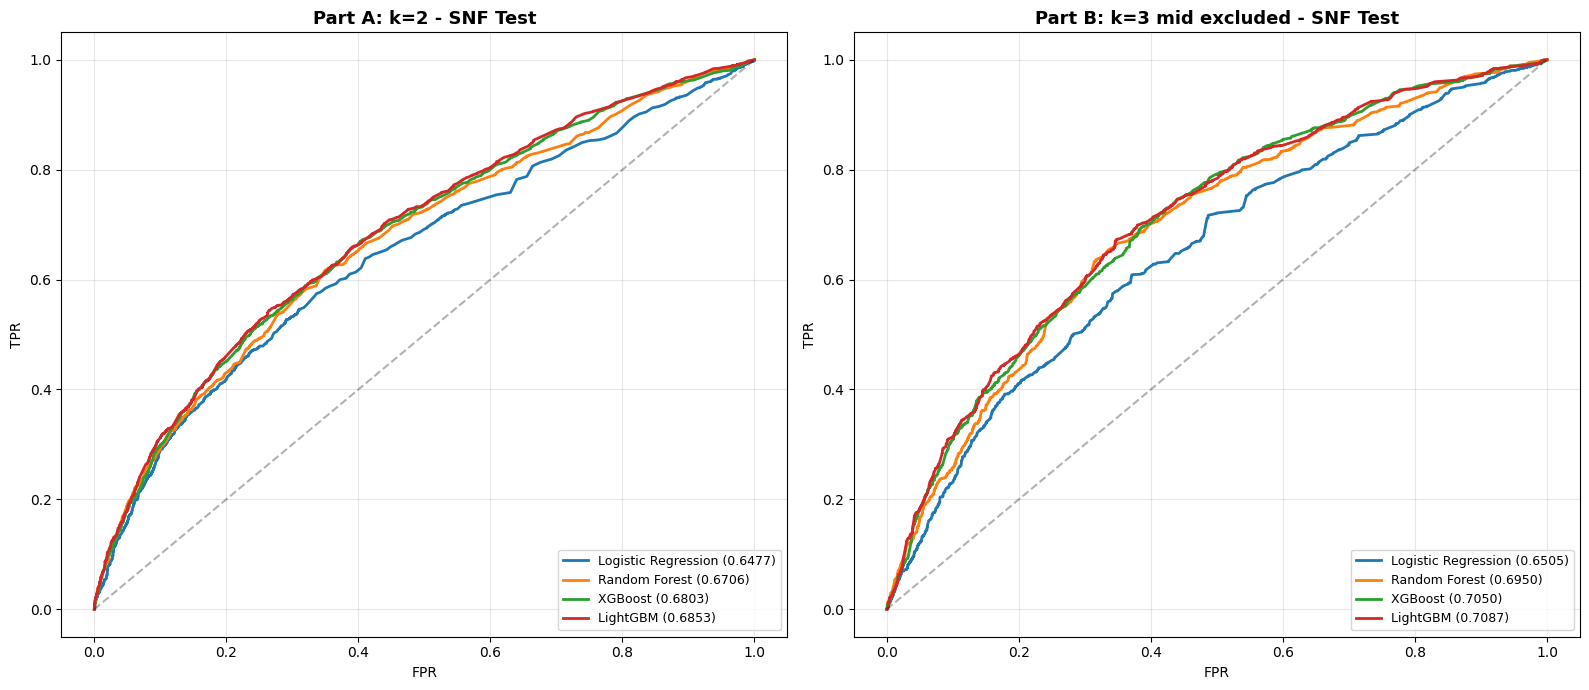

In [6]:
# =============================================================
# ROC Curve 비교
# =============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
for mname, res in r_a1.items():
    fpr, tpr, _ = roc_curve(res['y_test'], res['prob_test'])
    ax.plot(fpr, tpr, lw=2, label=f"{mname} ({res['auc_test']:.4f})")
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_title('Part A: k=2 - SNF Test', fontsize=13, fontweight='bold')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.legend(loc='lower right', fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
for mname, res in r_b1.items():
    fpr, tpr, _ = roc_curve(res['y_test'], res['prob_test'])
    ax.plot(fpr, tpr, lw=2, label=f"{mname} ({res['auc_test']:.4f})")
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_title('Part B: k=3 mid excluded - SNF Test', fontsize=13, fontweight='bold')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.legend(loc='lower right', fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('divs_enhanced_roc.png', dpi=150)
plt.show()

In [7]:
# =============================================================
# 최종 비교 요약
# =============================================================
model_names = list(get_models().keys())
short_map = {
    'Logistic Regression': 'LR',
    'Random Forest': 'RF',
    'XGBoost': 'XGB',
    'LightGBM': 'LGBM'
}
short_names = [short_map[m] for m in model_names]

print(f"\n{'#'*60}")
print("최종 비교 요약 (Test AUC)")
print(f"{'#'*60}")

header = f"  {'실험':<35s}" + "".join(f" {s:>8s}" for s in short_names)
print(f"\n{header}")
print("  " + "-" * (35 + 9 * len(short_names)))

all_results = [
    ("A-1 요양원 (k=2)", r_a1),
    ("A-2 비요양원 (k=2)", r_a2),
    ("A-3 혼합 (k=2)", r_a3),
    ("B-1 요양원 (k=3 mid제외)", r_b1),
    ("B-2 비요양원 (k=3 mid제외)", r_b2),
    ("B-3 혼합 (k=3 mid제외)", r_b3),
]

for exp_name, res in all_results:
    vals = "".join(f" {res[m]['auc_test']:8.4f}" for m in model_names)
    print(f"  {exp_name:<35s}{vals}")

# Train vs Test 비교 (과적합 확인)
print(f"\n{'#'*60}")
print("Train vs Test AUC 비교 (과적합 확인)")
print(f"{'#'*60}")

header2 = f"  {'실험':<35s}" + "".join(f" {s+' Tr':>8s} {s+' Te':>8s}" for s in short_names)
print(f"\n{header2}")
print("  " + "-" * (35 + 17 * len(short_names)))

for exp_name, res in all_results:
    vals = "".join(
        f" {res[m]['auc_train']:8.4f} {res[m]['auc_test']:8.4f}"
        for m in model_names)
    print(f"  {exp_name:<35s}{vals}")

print(f"\n[실루엣]  k=2: {sil2:.4f}  |  k=3 (중간 제외): {sil3:.4f}")
print(f"\n{'#'*60}")

























############################################################
최종 비교 요약 (Test AUC)
############################################################

  실험                                        LR       RF      XGB     LGBM
  -----------------------------------------------------------------------
  A-1 요양원 (k=2)                         0.6477   0.6706   0.6803   0.6853
  A-2 비요양원 (k=2)                        0.6347   0.6959   0.7192   0.7212
  A-3 혼합 (k=2)                          0.6439   0.6948   0.7111   0.7115
  B-1 요양원 (k=3 mid제외)                   0.6505   0.6950   0.7050   0.7087
  B-2 비요양원 (k=3 mid제외)                  0.6772   0.7428   0.7580   0.7617
  B-3 혼합 (k=3 mid제외)                    0.6678   0.7294   0.7493   0.7502

############################################################
Train vs Test AUC 비교 (과적합 확인)
############################################################

  실험                                     LR Tr    LR Te    RF Tr    RF Te   XGB Tr   XGB Te  LGBM Tr  LGBM Te


In [10]:
# =============================================================
# Train/Test 데이터 엑셀 반출
# =============================================================
import openpyxl

def export_split(X_data, y_data, label_name, filename, snf_flag=None):
    """Train/Test 8:2 split 후 각각 엑셀로 저장"""
    X = X_data.copy()
    y = np.array(y_data)

    if snf_flag is not None:
        stratify_key = y * 10 + snf_flag.astype(int)
        X_train, X_test, y_train, y_test, snf_tr, snf_te = train_test_split(
            X, y, snf_flag,
            test_size=0.2, random_state=random_state, stratify=stratify_key)
        X_train = X_train.copy()
        X_test = X_test.copy()
        X_train['IS_SNF'] = snf_tr.astype(int)
        X_test['IS_SNF'] = snf_te.astype(int)
    else:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=random_state, stratify=y)

    X_train = X_train.copy()
    X_test = X_test.copy()
    X_train['LABEL'] = y_train
    X_test['LABEL'] = y_test

    with pd.ExcelWriter(filename, engine='openpyxl') as writer:
        X_train.to_excel(writer, sheet_name='Train', index=False)
        X_test.to_excel(writer, sheet_name='Test', index=False)

    print(f"  ✅ {filename} (Train: {len(X_train)}, Test: {len(X_test)})")

print(f"\n{'='*60}")
print("Train/Test 데이터 엑셀 반출")
print(f"{'='*60}")

# Part A: k=2
export_split(
    df_snf[cols_11].reset_index(drop=True), y_snf_2,
    "k2_label", "A1_snf_k2.xlsx")

export_split(
    df_non_snf[cols_11].reset_index(drop=True), y_non_snf_2,
    "k2_label", "A2_nonsnf_k2.xlsx")

export_split(
    X_all_a, y_all_a,
    "k2_label", "A3_mixed_k2.xlsx", snf_flag=snf_flag_a)

# Part B: k=3 중간 제외
export_split(
    df_snf[cols_11].iloc[snf_keep].reset_index(drop=True),
    y_snf_3_full[snf_keep],
    "k3_label", "B1_snf_k3.xlsx")

export_split(
    df_non_snf[cols_11].iloc[non_snf_keep].reset_index(drop=True),
    y_non_snf_3_full[non_snf_keep],
    "k3_label", "B2_nonsnf_k3.xlsx")

export_split(
    X_mix_b, y_mix_b,
    "k3_label", "B3_mixed_k3.xlsx", snf_flag=snf_mix_b)

print(f"\n총 6개 파일 저장 완료!")


Train/Test 데이터 엑셀 반출
  ✅ A1_snf_k2.xlsx (Train: 25594, Test: 6399)
  ✅ A2_nonsnf_k2.xlsx (Train: 124016, Test: 31004)
  ✅ A3_mixed_k2.xlsx (Train: 149610, Test: 37403)
  ✅ B1_snf_k3.xlsx (Train: 12669, Test: 3168)
  ✅ B2_nonsnf_k3.xlsx (Train: 58318, Test: 14580)
  ✅ B3_mixed_k3.xlsx (Train: 70988, Test: 17747)

총 6개 파일 저장 완료!


In [9]:
# =============================================================
# B-3 혼합 실험 변수 중요도 (Train 기준)
# =============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

print(f"\n{'='*60}")
print("B-3 혼합 (k=3, 중간 제외) - 변수 중요도")
print(f"{'='*60}")

# 데이터 준비 (B-3와 동일)
X_b3 = pd.get_dummies(X_mix_b, drop_first=True).astype(float)
y_b3 = y_mix_b

# Train/Test split (B-3와 동일한 방식)
stratify_key = y_b3 * 10 + snf_mix_b.astype(int)
X_train_b3, X_test_b3, y_train_b3, y_test_b3 = train_test_split(
    X_b3, y_b3, test_size=0.2, random_state=random_state, stratify=stratify_key)

# 스케일링
scaler_b3 = StandardScaler()
X_train_b3_s = scaler_b3.fit_transform(X_train_b3)

# LR + RF 학습
lr_b3 = LogisticRegression(random_state=random_state, max_iter=1000)
lr_b3.fit(X_train_b3_s, y_train_b3)

rf_b3 = RandomForestClassifier(
    n_estimators=200, max_depth=10, min_samples_leaf=20,
    random_state=random_state, n_jobs=-1)
rf_b3.fit(X_train_b3_s, y_train_b3)

# 변수 중요도 출력
print(f"\n  {'변수':25s} {'LR 계수':>10s} {'RF 중요도':>10s}")
print("  " + "-" * 47)

coef_b3 = pd.DataFrame({
    'variable': X_b3.columns,
    'lr_coef': lr_b3.coef_[0],
    'rf_imp': rf_b3.feature_importances_
}).sort_values('rf_imp', ascending=False)

for _, r in coef_b3.iterrows():
    print(f"  {r['variable']:25s} {r['lr_coef']:+10.4f} {r['rf_imp']:10.4f}")


B-3 혼합 (k=3, 중간 제외) - 변수 중요도

  변수                             LR 계수     RF 중요도
  -----------------------------------------------
  AGE                          +0.2589     0.3663
  CANCER_YN                    +0.3275     0.2277
  STEROID_YN                   +0.3141     0.2108
  GENDER_M                     +0.1398     0.0529
  CKD_YN                       +0.0907     0.0423
  CHF_YN                       +0.0498     0.0309
  COPD_YN                      -0.0348     0.0216
  ANTIPSYCHOTIC_YN             +0.0434     0.0151
  PARKINSON_YN                 -0.0850     0.0110
  IMMUNOSUP_YN                 +0.0081     0.0107
  DEMENTIA_YN                  -0.0541     0.0106
